In [1]:
#Neural Network
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


data = load_breast_cancer()

X = data.data
y = data.target

print("========== DATASET ==========")
print("Dataset Shape :", X.shape)
print("Target Shape  :", y.shape)
print("Classes       :", data.target_names)
print("Features      :", len(data.feature_names))
print("\nFirst 5 Feature Names:")
print(data.feature_names[:5])




========== DATASET ==========
Dataset Shape : (569, 30)
Target Shape  : (569,)
Classes       : ['malignant' 'benign']
Features      : 30

First 5 Feature Names:
['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness']


Sample rows:



,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
204,12.47,18.60,81.09,481.9,0.09965,0.1058,0.08005,0.03821,0.1925,0.06373,...,24.64,96.05,677.9,0.1426,0.2378,0.2671,0.10150,0.3014,0.08750,1
70,18.94,21.31,123.60,1130.0,0.09009,0.1029,0.10800,0.07951,0.1582,0.05461,...,26.58,165.90,1866.0,0.1193,0.2336,0.2687,0.17890,0.2551,0.06589,0
131,15.46,19.48,101.70,748.9,0.10920,0.1223,0.14660,0.08087,0.1931,0.05796,...,26.00,124.90,1156.0,0.1546,0.2394,0.3791,0.15140,0.2837,0.08019,0
431,12.40,17.68,81.47,467.8,0.10540,0.1316,0.07741,0.02799,0.1811,0.07102,...,22.91,89.61,515.8,0.1450,0.2629,0.2403,0.07370,0.2556,0.09359,1
540,11.54,14.44,74.65,402.9,0.09984,0.1120,0.06737,0.02594,0.1818,0.06782,...,19.68,78.78,457.8,0.1345,0.2118,0.1797,0.06918,0.2329,0.08134,1



Class balance:
benign       357
malignant    212
Name: count, dtype: int64


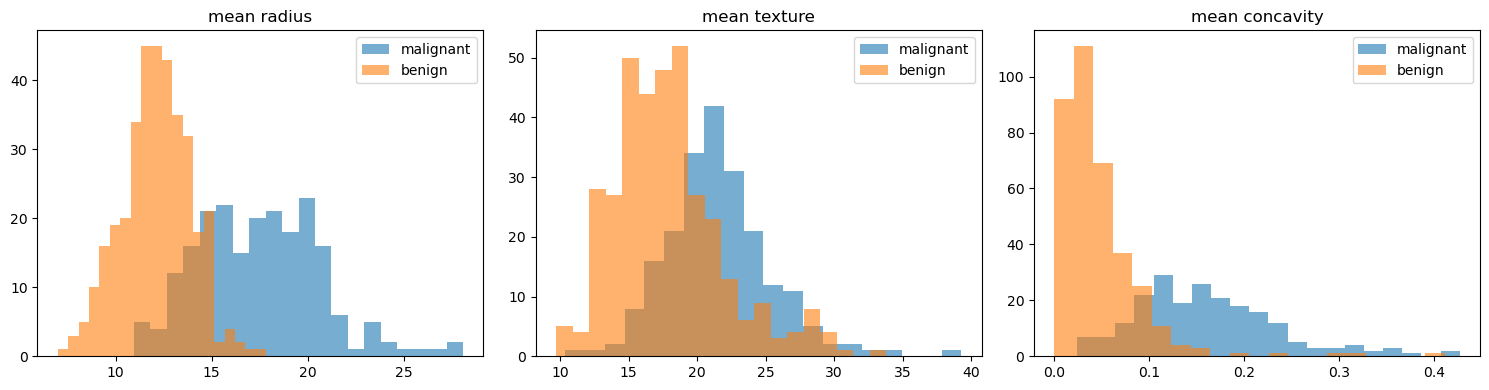

In [2]:
# ---- Dataset Overview ----
import pandas as pd
import matplotlib.pyplot as plt

df_view = pd.DataFrame(X, columns=data.feature_names)
df_view["target"] = y

print("Sample rows:\n")
display(df_view.sample(5, random_state=42))

print("\nClass balance:")
print(pd.Series(y).map({0: data.target_names[0], 1: data.target_names[1]}).value_counts())

# Distribution of a few key features, split by class
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, feat in zip(axes, ["mean radius", "mean texture", "mean concavity"]):
    for label, name in enumerate(data.target_names):
        ax.hist(df_view[df_view["target"] == label][feat], bins=20, alpha=0.6, label=name)
    ax.set_title(feat)
    ax.legend()
plt.tight_layout()
plt.show()

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

print("\n========== DATA SPLIT ==========")
print("Training Samples :", len(X_train))
print("Testing Samples  :", len(X_test))

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


model = MLPClassifier(
    hidden_layer_sizes=(20,10),
    activation="relu",
    solver="adam",
    max_iter=2000,
    random_state=42,
    verbose=True       # <-- Prints training progress
)

print("\n========== MODEL ==========")
print(model)


print("\n========== TRAINING ==========")

model.fit(X_train, y_train)

print("\nTraining Completed!")


pred = model.predict(X_test)

print("\n========== SAMPLE PREDICTIONS ==========")

for i in range(10):
    print(
        f"Actual: {y_test[i]}   Predicted: {pred[i]}"
    )

print("\n========== EVALUATION ==========")

print("Accuracy :", accuracy_score(y_test, pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, pred))

print("\nClassification Report")
print(classification_report(y_test, pred))


========== DATA SPLIT ==========
Training Samples : 455
Testing Samples  : 114

========== MODEL ==========
MLPClassifier(hidden_layer_sizes=(20, 10), max_iter=2000, random_state=42,
              verbose=True)

========== TRAINING ==========
Iteration 1, loss = 0.93431575
Iteration 2, loss = 0.89610162
Iteration 3, loss = 0.86032294
Iteration 4, loss = 0.82612537
Iteration 5, loss = 0.79464411
Iteration 6, loss = 0.76335434
Iteration 7, loss = 0.73432505
Iteration 8, loss = 0.70681489
Iteration 9, loss = 0.67927019
Iteration 10, loss = 0.65305119
Iteration 11, loss = 0.62691308
Iteration 12, loss = 0.60111528
Iteration 13, loss = 0.57596718
Iteration 14, loss = 0.55036760
Iteration 15, loss = 0.52503696
Iteration 16, loss = 0.50055158
Iteration 17, loss = 0.47623167
Iteration 18, loss = 0.45304964
Iteration 19, loss = 0.42986425
Iteration 20, loss = 0.40815660
Iteration 21, loss = 0.38676648
Iteration 22, loss = 0.36650603
Iteration 23, loss = 0.34751839
Iteration 24, loss = 0.329445

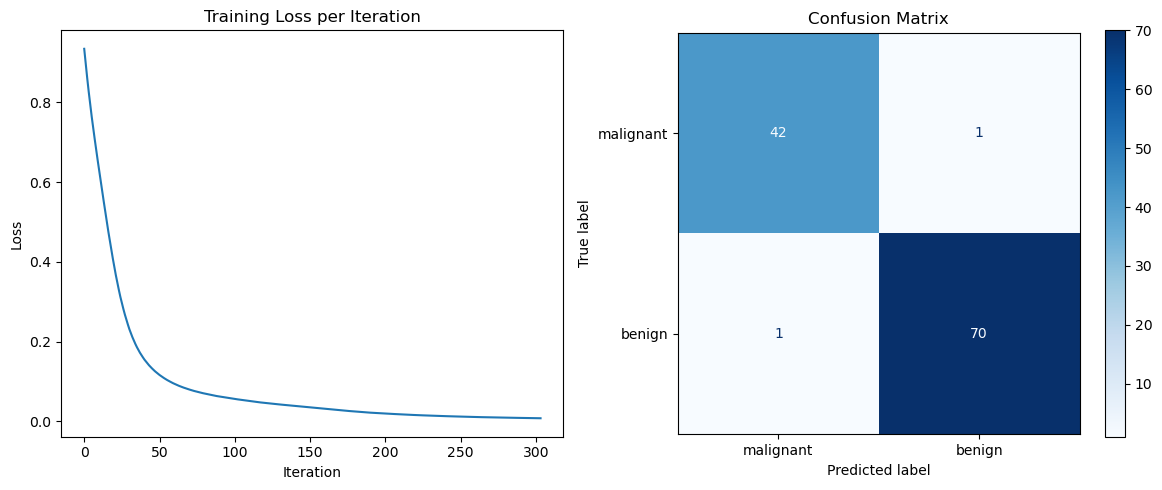

Model converged in 304 iterations (max was set to 2000).


In [5]:
# ---- Training Curve & Results ----
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Loss vs. iteration — shows how training converged
axes[0].plot(model.loss_curve_)
axes[0].set_title("Training Loss per Iteration")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Loss")

# Confusion matrix — shows final classification results
ConfusionMatrixDisplay.from_predictions(
    y_test, pred, display_labels=data.target_names, ax=axes[1], cmap="Blues"
)
axes[1].set_title("Confusion Matrix")

plt.tight_layout()
plt.show()

print(f"Model converged in {model.n_iter_} iterations (max was set to {model.max_iter}).")

In [4]:
#Reinforcement Learning

import numpy as np

# Reward Matrix
R = np.array([
    [-1, 0, -1],    # State 0 -> State 1
    [0, -1, 100],   # State 1 -> State 0 or Goal
    [-1, -1, 100]   # Goal State
])

# Initialize Q-table
Q = np.zeros((3,3))

gamma = 0.8
alpha = 0.5
episodes = 5

for episode in range(episodes):

    print("="*40)
    print(f"Episode {episode+1}")
    print("="*40)

    state = 0
    print("Starting State:", state)

    while state != 2:

        # Find valid actions
        actions = np.where(R[state] >= 0)[0]
        print("Possible Actions:", actions)

        # Choose one action randomly
        action = np.random.choice(actions)
        print("Chosen Action:", action)

        reward = R[state, action]
        next_state = action

        old_q = Q[state, action]

        # Q-learning Update
        Q[state, action] = old_q + alpha * (
            reward +
            gamma * np.max(Q[next_state]) -
            old_q
        )

        print("Reward Received:", reward)
        print("Old Q-value:", round(old_q,2))
        print("Updated Q-value:", round(Q[state, action],2))
        print()

        state = next_state

    print("Reached Goal!")

    print("\nQ Table after Episode", episode+1)
    print(np.round(Q,2))
    print()

Episode 1
Starting State: 0
Possible Actions: [1]
Chosen Action: 1
Reward Received: 0
Old Q-value: 0.0
Updated Q-value: 0.0

Possible Actions: [0 2]
Chosen Action: 2
Reward Received: 100
Old Q-value: 0.0
Updated Q-value: 50.0

Reached Goal!

Q Table after Episode 1
[[ 0.  0.  0.]
 [ 0.  0. 50.]
 [ 0.  0.  0.]]

Episode 2
Starting State: 0
Possible Actions: [1]
Chosen Action: 1
Reward Received: 0
Old Q-value: 0.0
Updated Q-value: 20.0

Possible Actions: [0 2]
Chosen Action: 0
Reward Received: 0
Old Q-value: 0.0
Updated Q-value: 8.0

Possible Actions: [1]
Chosen Action: 1
Reward Received: 0
Old Q-value: 20.0
Updated Q-value: 30.0

Possible Actions: [0 2]
Chosen Action: 2
Reward Received: 100
Old Q-value: 50.0
Updated Q-value: 75.0

Reached Goal!

Q Table after Episode 2
[[ 0. 30.  0.]
 [ 8.  0. 75.]
 [ 0.  0.  0.]]

Episode 3
Starting State: 0
Possible Actions: [1]
Chosen Action: 1
Reward Received: 0
Old Q-value: 30.0
Updated Q-value: 45.0

Possible Actions: [0 2]
Chosen Action: 0
Reward